# Activity 2 – Random Forest Classification
**Dataset:** Seattle Weather | TC2004B — A01286400

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.utils import resample
import warnings; warnings.filterwarnings('ignore')

## 1. Load Data & Class Balance Analysis

In [13]:
df = pd.read_csv('../../../data/s2/seattle-weather.csv').drop(columns=['date'])
X = df.drop(columns=['weather'])
y = df['weather']
counts_before = y.value_counts()
print('Class distribution before balancing:')
print(counts_before)
print('\nDataset is imbalanced — rain/sun dominate (641/640), snow is very rare (26).')

Class distribution before balancing:
weather
rain       641
sun        640
fog        101
drizzle     53
snow        26
Name: count, dtype: int64

Dataset is imbalanced — rain/sun dominate (641/640), snow is very rare (26).


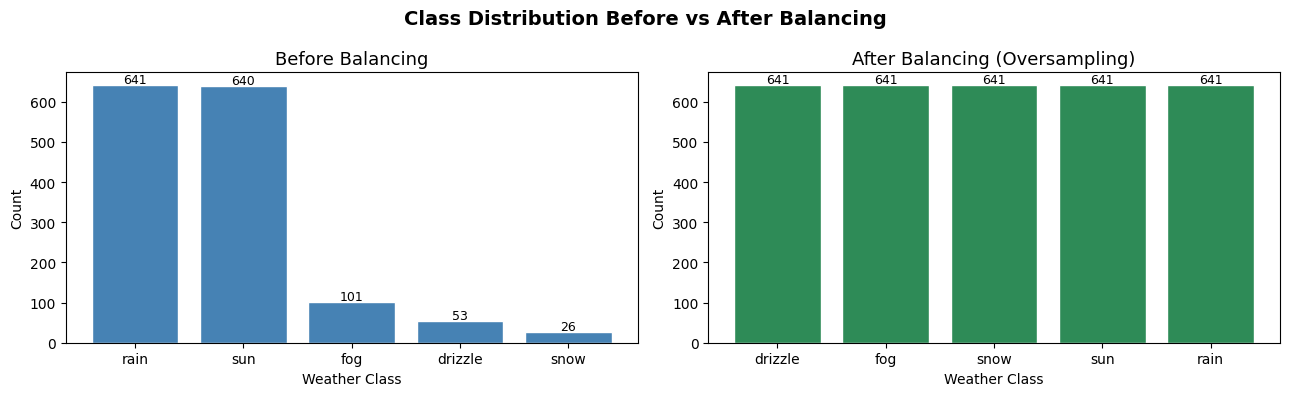

Balanced: 3205 samples total (641 per class)


In [14]:
# Oversample minority classes
df_combined = pd.concat([X, y], axis=1)
max_count = counts_before.max()
dfs = [resample(df_combined[df_combined['weather'] == lbl],
               replace=True, n_samples=max_count, random_state=42)
       for lbl in y.unique()]
df_bal = pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)
X_bal = df_bal.drop('weather', axis=1)
y_bal = df_bal['weather']
counts_after = y_bal.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(counts_before.index, counts_before.values, color='steelblue', edgecolor='white')
axes[0].set_title('Before Balancing', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts_before.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)
axes[1].bar(counts_after.index, counts_after.values, color='seagreen', edgecolor='white')
axes[1].set_title('After Balancing (Oversampling)', fontsize=13)
axes[1].set_ylabel('Count')
for i, v in enumerate(counts_after.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=9)
for ax in axes:
    ax.set_xlabel('Weather Class')
plt.suptitle('Class Distribution Before vs After Balancing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Balanced: {len(y_bal)} samples total ({max_count} per class)')

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.3, random_state=42, stratify=y_bal)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]} (70/30 split)')

Train: 2243 | Test: 962 (70/30 split)


## 2. Default Random Forest (No Optimization)

In [16]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

depths = [tree.get_depth() for tree in rf.estimators_]
print(f'Number of trees: {rf.n_estimators}')
print(f'Average tree depth: {np.mean(depths):.1f} (min: {min(depths)}, max: {max(depths)})')
print()
print(classification_report(y_test, y_pred))

Number of trees: 100
Average tree depth: 19.3 (min: 16, max: 26)

              precision    recall  f1-score   support

     drizzle       0.95      1.00      0.97       193
         fog       0.93      0.99      0.96       192
        rain       0.99      0.96      0.98       192
        snow       0.98      1.00      0.99       193
         sun       0.98      0.87      0.92       192

    accuracy                           0.97       962
   macro avg       0.97      0.97      0.97       962
weighted avg       0.97      0.97      0.97       962



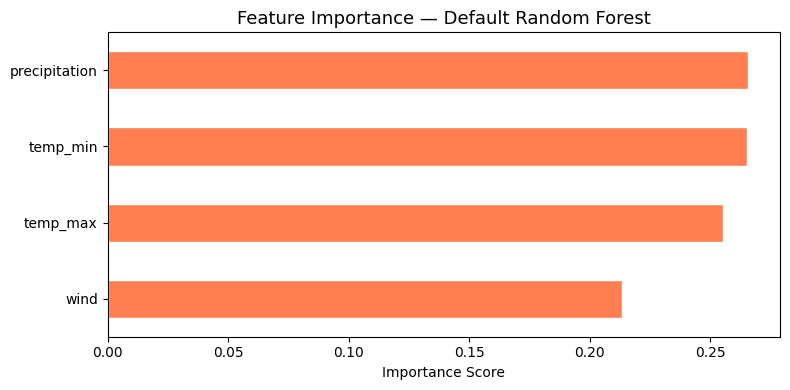

Most important feature: precipitation


In [17]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
feat_imp.plot(kind='barh', ax=ax, color='coral', edgecolor='white')
ax.set_title('Feature Importance — Default Random Forest', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()
print('Most important feature:', feat_imp.idxmax())

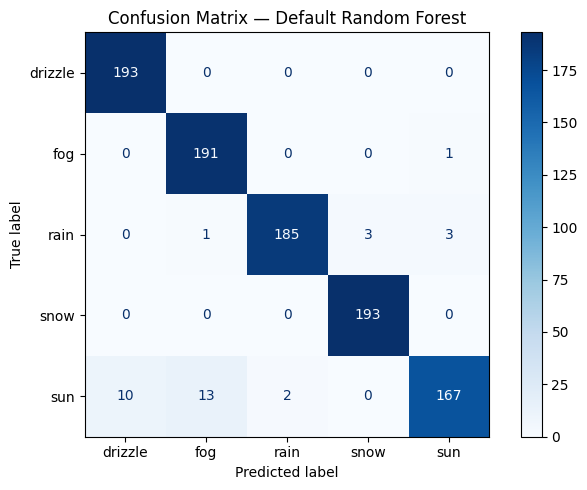

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix — Default Random Forest')
plt.tight_layout()
plt.show()

## 3. Optimized Random Forest (GridSearchCV)

In [20]:
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 15, 30, 60, 120],
    'min_samples_split': [1, 2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid,
                   cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
print('Best hyperparameters:')
for k, v in grid.best_params_.items():
    print(f'  {k}: {v}')
print(f'Best CV accuracy: {grid.best_score_:.4f}')

Best hyperparameters:
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 100
Best CV accuracy: 0.9559


In [21]:
rf_opt = grid.best_estimator_
y_pred_opt = rf_opt.predict(X_test)
depths_opt = [tree.get_depth() for tree in rf_opt.estimators_]
print(f'Trees: {rf_opt.n_estimators} | Avg depth: {np.mean(depths_opt):.1f}')
print()
print(classification_report(y_test, y_pred_opt))

Trees: 100 | Avg depth: 19.3

              precision    recall  f1-score   support

     drizzle       0.95      1.00      0.97       193
         fog       0.93      0.99      0.96       192
        rain       0.99      0.96      0.98       192
        snow       0.98      1.00      0.99       193
         sun       0.98      0.87      0.92       192

    accuracy                           0.97       962
   macro avg       0.97      0.97      0.97       962
weighted avg       0.97      0.97      0.97       962



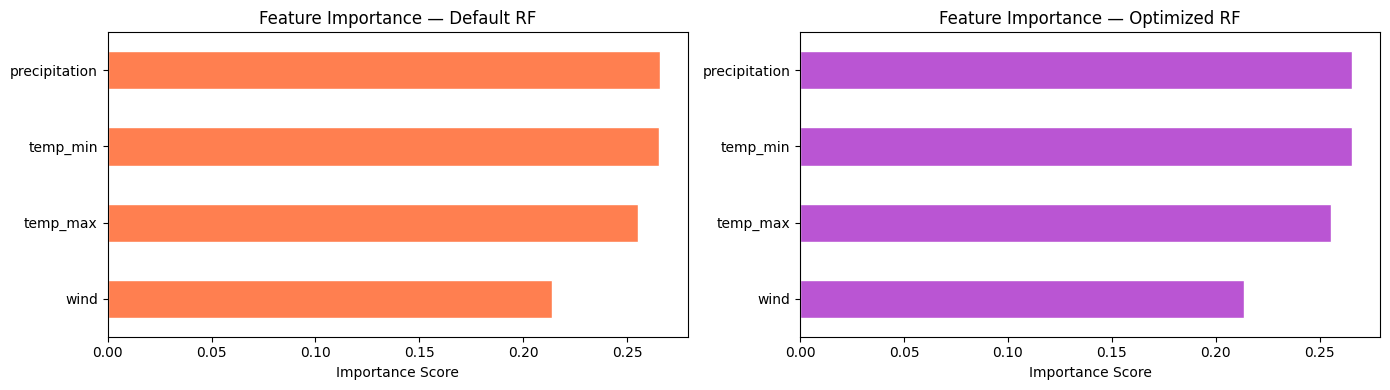

In [22]:
feat_imp_opt = pd.Series(rf_opt.feature_importances_, index=X.columns).sort_values()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
feat_imp.plot(kind='barh', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Feature Importance — Default RF')
feat_imp_opt.plot(kind='barh', ax=axes[1], color='mediumorchid', edgecolor='white')
axes[1].set_title('Feature Importance — Optimized RF')
for ax in axes:
    ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

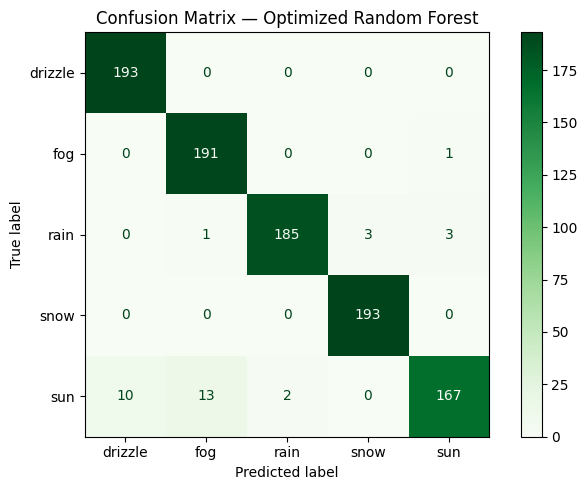

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_opt, ax=ax, cmap='Greens')
ax.set_title('Confusion Matrix — Optimized Random Forest')
plt.tight_layout()
plt.show()

## 4. Comparison & Reflection

**Default RF (100 trees, no constraints):** Deep trees, high variance. Performs well but may overfit.

**Optimized RF:** GridSearchCV tuned:
- `n_estimators` — more trees → lower variance. Beyond a point, diminishing returns.
- `max_depth` — limits each tree's complexity, prevents overfitting
- `min_samples_split` / `min_samples_leaf` — prevent splits on noise, improve generalization
- `max_features` — `sqrt` means each tree sees a random subset of features → reduces correlation between trees

**Random Forest vs single Decision Tree:**
- RF aggregates many trees → dramatically reduces variance
- Individual trees in RF are trained on random bootstrap samples
- RF is much more robust than a single DT.
- Trade-off: RF is less interpretable than a single decision tree

**Feature importance:** `precipitation` and `temp_max` are typically the most important predictors for weather classification in Seattle.